<a href="https://colab.research.google.com/github/2d-game-dev/ComputerVisionProject/blob/main/Copy_of_NEWERVersionOFCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ce2bdqFeT7e9MGJbnEPa")
project = rf.workspace("my-workspace-y2ace").project("cctv-naxyo-drk6y")
dataset = project.version(1).download("yolov5")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 150.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to cctv-1 in yolov5pytorch:: 100%|██████████| 7479/7479 [00:04<00:00, 1776.78it/s]


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

In [15]:
class GridDataset(Dataset):
    def __init__(self, images_path, labels_path, grid_size=7, max_images=None):
        self.images = []
        self.labels = []
        self.grid_size = grid_size

        img_files = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.png'))]

        # ✅ use all images unless max_images is set
        if max_images:
            img_files = img_files[:max_images]

        for img_file in img_files:
            label_file = img_file.replace('.jpg', '.txt').replace('.png', '.txt')
            label_path = os.path.join(labels_path, label_file)

            grid = np.zeros((grid_size, grid_size, 5))

            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    for line in f.readlines():
                        parts = line.strip().split()
                        if len(parts) == 5:
                            _, x, y, w, h = map(float, parts)

                            gx = int(x * grid_size)
                            gy = int(y * grid_size)

                            if gx < grid_size and gy < grid_size:
                                grid[gy, gx] = [1, x, y, w, h]

            self.images.append(os.path.join(images_path, img_file))
            self.labels.append(grid)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        img = img.resize((224, 224))
        img = np.array(img) / 255.0
        img = torch.FloatTensor(img).permute(2, 0, 1)

        label = torch.FloatTensor(self.labels[idx])
        return img, label

In [16]:
class GridDetectionModel(nn.Module):
    def __init__(self, grid_size=7):
        super().__init__()
        self.grid_size = grid_size

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.fc = nn.Linear(128 * 14 * 14, 1024)
        self.output = nn.Linear(1024, grid_size * grid_size * 5)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc(x))
        x = self.output(x)
        x = x.view(-1, self.grid_size, self.grid_size, 5)

        x[..., 0] = torch.sigmoid(x[..., 0])
        x[..., 1:] = torch.sigmoid(x[..., 1:])

        return x


In [19]:
def detection_loss(pred, target):
    obj_mask = target[..., 0] > 0

    loss_conf = ((pred[..., 0] - target[..., 0]) ** 2).mean()

    if obj_mask.sum() > 0:
        loss_bbox = ((pred[obj_mask][..., 1:] - target[obj_mask][..., 1:]) ** 2).mean()
    else:
        loss_bbox = 0

    return loss_conf + loss_bbox


In [18]:
dataset_path = "/content/cctv-1"

train_dataset = GridDataset(f"{dataset_path}/train/images", f"{dataset_path}/train/labels")
val_dataset   = GridDataset(f"{dataset_path}/valid/images", f"{dataset_path}/valid/labels")
test_dataset  = GridDataset(f"{dataset_path}/test/images",  f"{dataset_path}/test/labels")  # ✅ NEW

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)
test_loader  = DataLoader(test_dataset, batch_size=16)  # ✅ NEW

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GridDetectionModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(epochs):
    # ===== TRAIN =====
    model.train()
    total_train_loss = 0

    for images, targets in tqdm(train_loader):
        images, targets = images.to(device), targets.to(device)

        preds = model(images)
        loss = detection_loss(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ===== VALIDATION =====
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(device), targets.to(device)

            preds = model(images)
            loss = detection_loss(preds, targets)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # ✅ CHECKPOINTING (THIS IS THE KEY PART)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Best model saved!")

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f} | Val Loss = {avg_val_loss:.4f}")

100%|██████████| 192/192 [01:09<00:00,  2.78it/s]


✅ Best model saved!
Epoch 1: Train Loss = 0.0728 | Val Loss = 0.0576


100%|██████████| 192/192 [01:07<00:00,  2.84it/s]


✅ Best model saved!
Epoch 2: Train Loss = 0.0542 | Val Loss = 0.0506


100%|██████████| 192/192 [01:06<00:00,  2.88it/s]


...

Epoch 18: Train Loss = 0.0056 | Val Loss = 0.0432


100%|██████████| 192/192 [01:07<00:00,  2.86it/s]


Epoch 19: Train Loss = 0.0053 | Val Loss = 0.0435


100%|██████████| 192/192 [01:06<00:00,  2.89it/s]


Epoch 20: Train Loss = 0.0051 | Val Loss = 0.0425


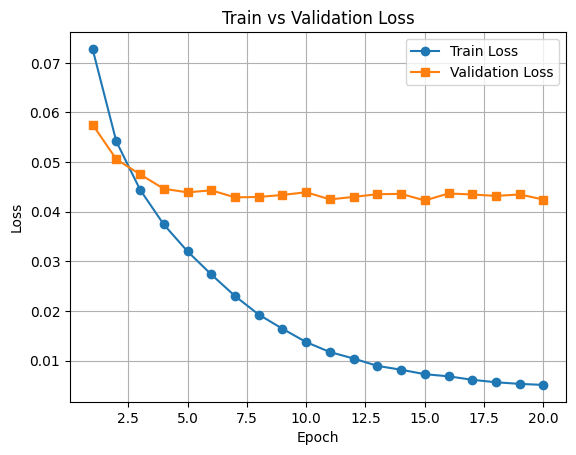

✅ Loaded best model for testing
TEST Accuracy: 88.7%


In [33]:
plt.figure()
plt.plot(range(1, epochs+1), train_losses, marker='o', label="Train Loss")
plt.plot(range(1, epochs+1), val_losses, marker='s', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

model.load_state_dict(torch.load("best_model.pth"))
print("✅ Loaded best model for testing")
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, targets in test_loader:
        images, targets = images.to(device), targets.to(device)
        preds = model(images)

        pred_has_person = preds[..., 0].amax(dim=(1,2)) > 0.3
        true_has_person = targets[..., 0].amax(dim=(1,2)) > 0.0

        correct += (pred_has_person == true_has_person).sum().item()
        total += images.size(0)

test_accuracy = 100 * correct / total

print(f"TEST Accuracy: {test_accuracy:.1f}%")


In [34]:
def detect_intrusion(model, image_path, restricted_zone=[0.3,0.4,0.7,0.6], threshold=0.1):
    model.eval()

    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize((224,224))
    img_tensor = torch.FloatTensor(np.array(img_resized)/255.0).permute(2,0,1).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_tensor)[0].cpu().numpy()

    print("Max confidence:", pred[...,0].max())

    intrusion = False
    boxes = []

    for i in range(pred.shape[0]):
        for j in range(pred.shape[1]):
            conf = pred[i,j,0]

            if conf > threshold:
                x, y, w, h = pred[i,j,1:]
                boxes.append((x,y,w,h))

                # ✅ NEW: box-overlap intrusion check
                # Box corners
                x1 = x - w/2
                y1 = y - h/2
                x2 = x + w/2
                y2 = y + h/2

                # Zone
                zx1, zy1, zx2, zy2 = restricted_zone

                # Check overlap
                if (x1 < zx2 and x2 > zx1 and y1 < zy2 and y2 > zy1):
                    intrusion = True

    # Visualization
    fig, ax = plt.subplots(1)
    ax.imshow(img)

    h_img, w_img = img.size[1], img.size[0]

    # Draw restricted zone
    rz = patches.Rectangle((restricted_zone[0]*w_img, restricted_zone[1]*h_img),
                           (restricted_zone[2]-restricted_zone[0])*w_img,
                           (restricted_zone[3]-restricted_zone[1])*h_img,
                           edgecolor='red', facecolor='red', alpha=0.3)
    ax.add_patch(rz)

    # Draw boxes
    for (x,y,w,h) in boxes:
        rect = patches.Rectangle(((x-w/2)*w_img,(y-h/2)*h_img),
                                 w*w_img,h*h_img,
                                 edgecolor='yellow', facecolor='none')
        ax.add_patch(rect)

    if intrusion:
        plt.title("🚨 INTRUSION DETECTED", color="red")
    else:
        plt.title("✅ SAFE")

    plt.axis('off')
    plt.show()

    return intrusion

Max confidence: 0.9988926


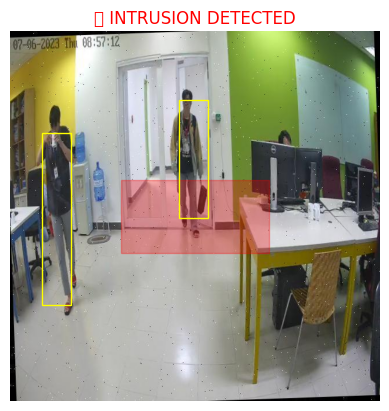

True

In [28]:
test_image = val_dataset.images[0]
detect_intrusion(model, test_image)

Frame 1
Max confidence: 0.9988926


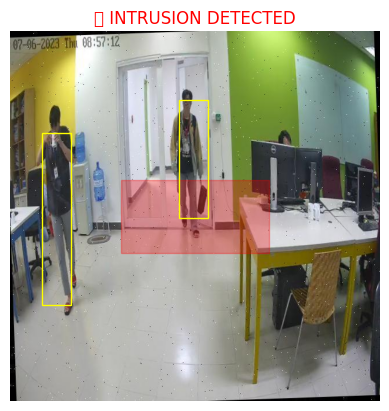

Frame 2
Max confidence: 0.8752135


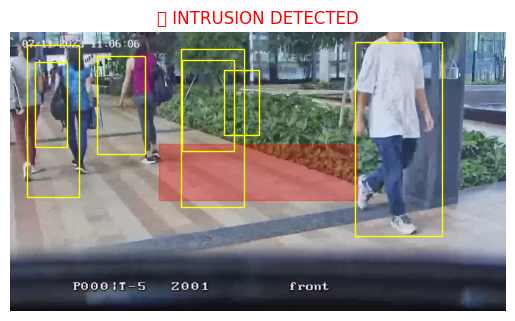

Frame 3
Max confidence: 0.8376001


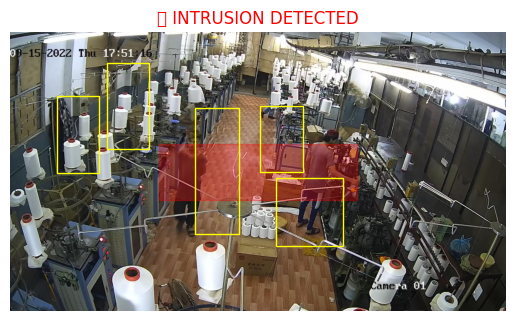

Frame 4
Max confidence: 0.9678169


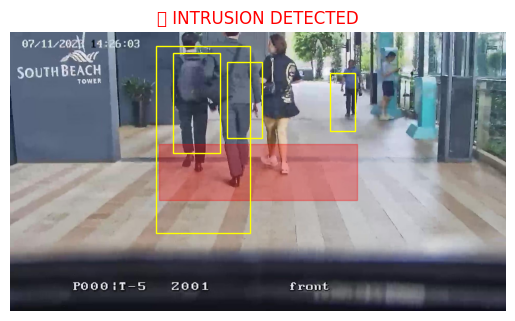

Frame 5
Max confidence: 0.73269725


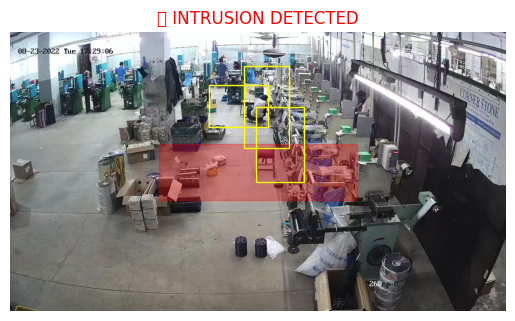

Frame 6
Max confidence: 0.7880471


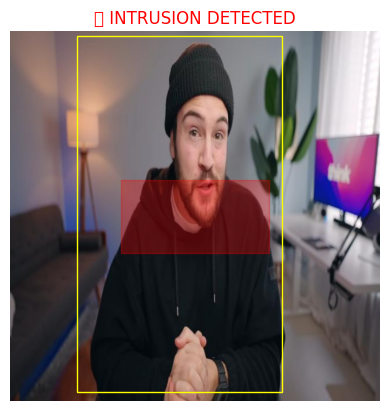

Frame 7
Max confidence: 0.98847723


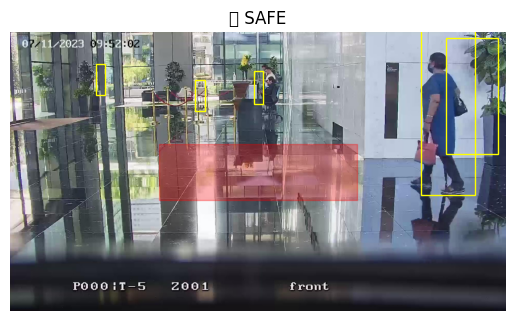

Frame 8
Max confidence: 0.9331963


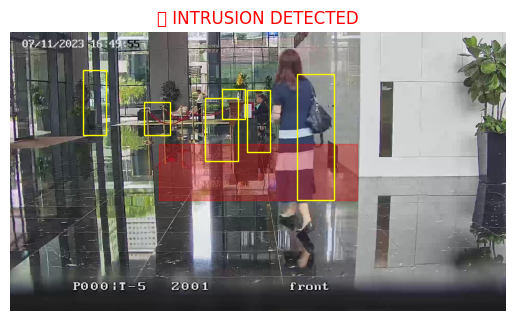

Frame 9
Max confidence: 0.45449674


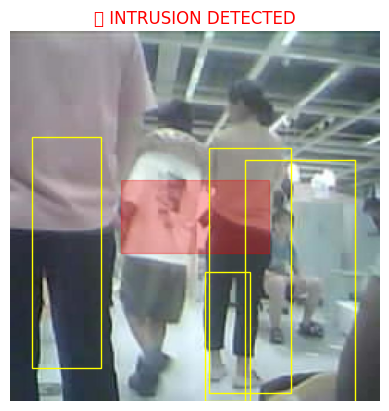

Frame 10
Max confidence: 0.71151924


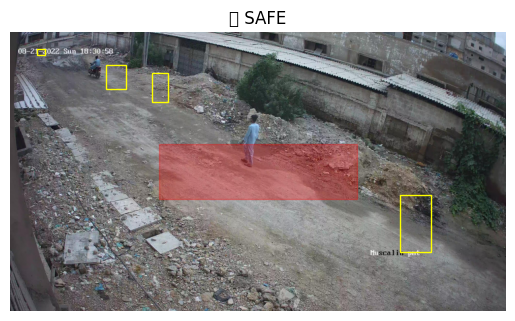

In [29]:
def simulate_cctv(model, folder, delay=1):
    images = os.listdir(folder)

    for i, img in enumerate(images[:10]):
        print(f"Frame {i+1}")
        detect_intrusion(model, os.path.join(folder, img))
        plt.pause(delay)

simulate_cctv(model, os.path.dirname(val_dataset.images[0]))

In [14]:
print("Train images:", len(os.listdir(f"{dataset_path}/train/images")))
print("Valid images:", len(os.listdir(f"{dataset_path}/valid/images")))
print("Test images:", len(os.listdir(f"{dataset_path}/test/images")))

Train images: 3060
Valid images: 526
Test images: 151
